# Eksperimen: Prediksi Survival Penumpang Titanic

## 1. Perkenalan Dataset

**Sumber dataset:** Titanic dataset, dataset publik klasik untuk klasifikasi biner
(survived / not survived) berisi data demografis dan tiket penumpang kapal Titanic.
Dataset diambil dari public repository (mirror `seaborn-data`, identik dengan dataset
Titanic yang umum dipakai di Kaggle/UCI).

**Target:** `survived` (0 = tidak selamat, 1 = selamat)

**Tipe data:** structured / tabular (campuran numerik & kategorikal)


### 1.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
print("Library berhasil di-import.")

Library berhasil di-import.


### 1.2 Memuat Dataset

In [2]:
df = pd.read_csv("../namadataset_raw/titanic_raw.csv")
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


## 2. Exploratory Data Analysis (EDA)

Tujuan tahap ini: memahami karakteristik dataset (distribusi, missing value,
duplikasi, hubungan antar fitur) sebelum menentukan langkah preprocessing.

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Cek missing value per kolom:**

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')

,missing_count,missing_pct
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


Kolom `deck` memiliki >77% missing value (terlalu sparse untuk diimputasi secara "
"andal), sedangkan `age` (177 baris) dan `embarked` (2 baris) masih layak diimputasi.

**Cek duplikasi data:**

In [6]:
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 107


**Cek kolom redundant (potensi data leakage / duplikasi informasi):**

In [7]:
print("alive == survived (encoded)?", (df['alive'].map({'no':0,'yes':1}) == df['survived']).all())
print("embarked vs embark_town, baris null sama?",
      df[df['embarked'].isnull()].index.tolist() == df[df['embark_town'].isnull()].index.tolist())

alive == survived (encoded)? True
embarked vs embark_town, baris null sama? True


Kolom `alive` identik dengan target `survived` (risiko *data leakage* jika dipakai
sebagai fitur), dan `embark_town` sepenuhnya redundant dengan `embarked`. Kolom
`class`, `who`, `adult_male` juga merupakan turunan langsung dari `pclass`, `age`,
`sex` — semua kolom ini akan dibuang di tahap preprocessing.

**Distribusi target (survival rate):**

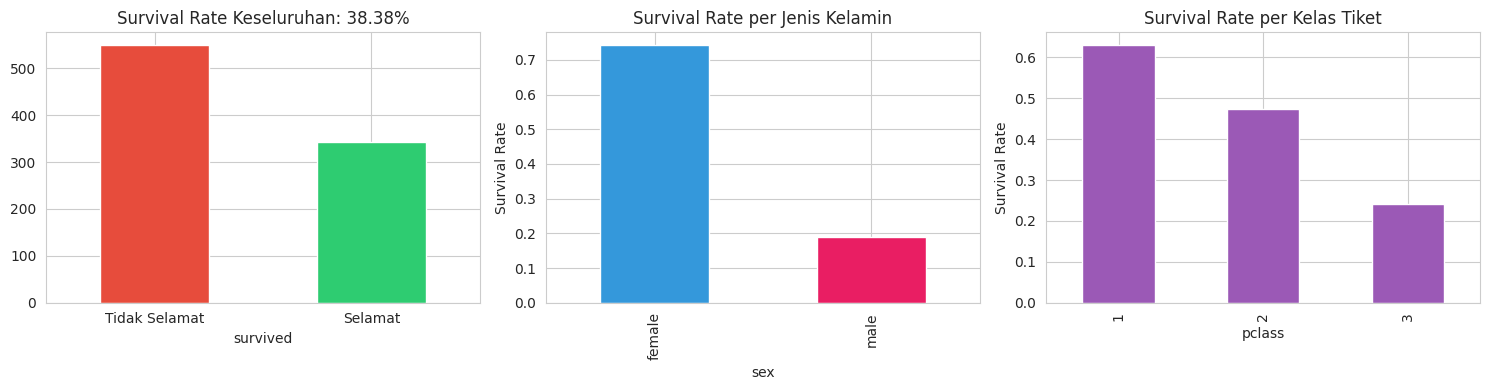

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df['survived'].value_counts().plot(kind='bar', ax=ax[0], color=['#e74c3c', '#2ecc71'])
ax[0].set_title(f"Survival Rate Keseluruhan: {df['survived'].mean():.2%}")
ax[0].set_xticklabels(['Tidak Selamat', 'Selamat'], rotation=0)

df.groupby('sex')['survived'].mean().plot(kind='bar', ax=ax[1], color=['#3498db', '#e91e63'])
ax[1].set_title("Survival Rate per Jenis Kelamin")
ax[1].set_ylabel("Survival Rate")

df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=ax[2], color='#9b59b6')
ax[2].set_title("Survival Rate per Kelas Tiket")
ax[2].set_ylabel("Survival Rate")
plt.tight_layout()
plt.savefig('eda_survival_overview.png', dpi=100)
plt.show()

**Distribusi fare & age, cek outlier:**

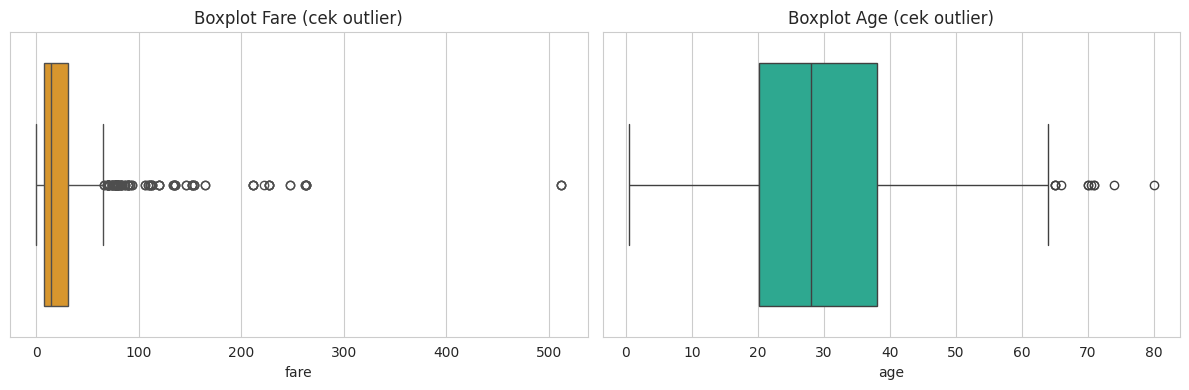

Fare - batas atas outlier (IQR): 65.63, jumlah outlier: 116


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['fare'], ax=ax[0], color='#f39c12')
ax[0].set_title('Boxplot Fare (cek outlier)')
sns.boxplot(x=df['age'].dropna(), ax=ax[1], color='#1abc9c')
ax[1].set_title('Boxplot Age (cek outlier)')
plt.tight_layout()
plt.savefig('eda_outlier_check.png', dpi=100)
plt.show()

Q1, Q3 = df['fare'].quantile(0.25), df['fare'].quantile(0.75)
upper = Q3 + 1.5 * (Q3 - Q1)
print(f"Fare - batas atas outlier (IQR): {upper:.2f}, jumlah outlier: {(df['fare'] > upper).sum()}")

**Korelasi antar fitur numerik:**

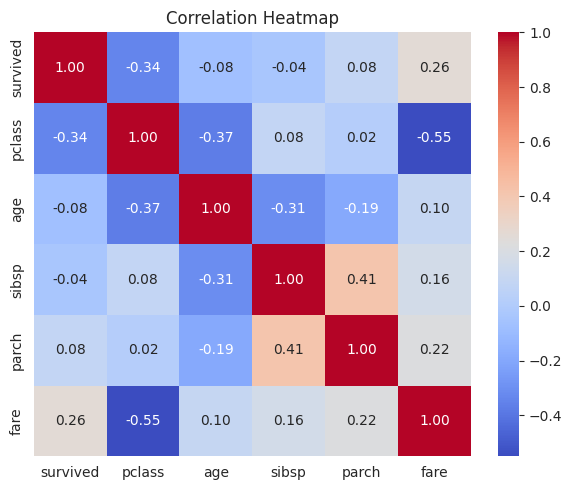

In [10]:
numeric_df = df[['survived','pclass','age','sibsp','parch','fare']]
plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=100)
plt.show()

## 3. Data Preprocessing

Berdasarkan hasil EDA di atas, berikut tahapan preprocessing yang dilakukan:

1. Membuang kolom redundant/leakage/terlalu sparse (`alive`, `embark_town`, `class`, `who`, `adult_male`, `deck`)
2. Menghapus data duplikat
3. Menangani missing value (`age` diimputasi median per kelompok `pclass`+`sex`, `embarked` diimputasi modus)
4. Menangani outlier pada `fare` (capping/winsorizing di persentil ke-99)
5. Feature engineering (`family_size`, `is_alone`) dan binning (`age_group`)
6. Encoding kategorikal (`sex` binary, `embarked` & `age_group` one-hot)
7. Standarisasi fitur numerik (`age`, `fare`, `family_size`)


In [11]:
df_clean = df.drop(columns=['alive', 'embark_town', 'class', 'who', 'adult_male', 'deck'])
print("Kolom setelah dibuang:", df_clean.columns.tolist())

Kolom setelah dibuang: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


In [12]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Duplikat dihapus: {before - len(df_clean)} baris ({before} -> {len(df_clean)})")

Duplikat dihapus: 111 baris (891 -> 780)


In [13]:
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['age'] = df_clean.groupby(['pclass','sex'])['age'].transform(lambda x: x.fillna(x.median()))
print("Sisa missing value:\n", df_clean.isnull().sum())

Sisa missing value:
 survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


In [14]:
fare_cap = df_clean['fare'].quantile(0.99)
df_clean['fare'] = np.where(df_clean['fare'] > fare_cap, fare_cap, df_clean['fare'])
print(f"Fare di-cap pada persentil ke-99: {fare_cap:.2f}")

Fare di-cap pada persentil ke-99: 262.38


In [15]:
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1
df_clean['is_alone'] = (df_clean['family_size'] == 1).astype(int)
df_clean['age_group'] = pd.cut(df_clean['age'], bins=[0,12,18,35,60,100],
                                labels=['child','teen','young_adult','adult','senior'])
df_clean[['sibsp','parch','family_size','is_alone','age_group']].head()

,sibsp,parch,family_size,is_alone,age_group
0,1,0,2,0,young_adult
1,1,0,2,0,adult
2,0,0,1,1,young_adult
3,1,0,2,0,young_adult
4,0,0,1,1,young_adult


In [16]:
df_clean['sex'] = df_clean['sex'].map({'male': 0, 'female': 1})
df_clean = pd.get_dummies(df_clean, columns=['embarked', 'age_group'], drop_first=True)
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)
df_clean.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone,family_size,is_alone,embarked_Q,embarked_S,age_group_teen,age_group_young_adult,age_group_adult,age_group_senior
0,0,3,0,22.0,1,0,7.2500,0,2,0,0,1,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,0,2,0,0,0,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,1,1,1,0,1,0,1,0,0
3,1,1,1,35.0,1,0,53.1000,0,2,0,0,1,0,1,0,0
4,0,3,0,35.0,0,0,8.0500,1,1,1,0,1,0,1,0,0


In [17]:
scaler = StandardScaler()
num_cols = ['age', 'fare', 'family_size']
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])
print("Fitur numerik berhasil distandarisasi.")
df_clean.describe().T[['mean','std','min','max']]

Fitur numerik berhasil distandarisasi.


,mean,std,min,max
survived,4.128205e-01,0.492657,0.000000,1.000000
pclass,2.246154e+00,0.854452,1.000000,3.000000
sex,3.743590e-01,0.484267,0.000000,1.000000
age,2.732857e-17,1.000642,-2.095033,3.620969
sibsp,5.256410e-01,0.988046,0.000000,8.000000
parch,4.179487e-01,0.838536,0.000000,6.000000
fare,3.985416e-18,1.000642,-0.748350,5.049700
alone,5.666667e-01,0.495854,0.000000,1.000000
family_size,-2.277381e-18,1.000642,-0.621230,5.962458
is_alone,5.666667e-01,0.495854,0.000000,1.000000


**Simpan dataset hasil preprocessing (siap dilatih):**

In [18]:
import os
os.makedirs('namadataset_preprocessing', exist_ok=True)
df_clean.to_csv('namadataset_preprocessing/titanic_preprocessed.csv', index=False)
print("Shape akhir dataset siap latih:", df_clean.shape)
print("Disimpan ke: namadataset_preprocessing/titanic_preprocessed.csv")

Shape akhir dataset siap latih: (780, 16)
Disimpan ke: namadataset_preprocessing/titanic_preprocessed.csv


## Kesimpulan

Dataset mentah (891 baris, 15 kolom) berhasil diproses menjadi dataset siap latih
(780 baris setelah dedup, 16 kolom fitur+target) tanpa missing value, dengan fitur
kategorikal ter-encode dan fitur numerik ter-standarisasi. Proses ini selanjutnya
dikonversi menjadi skrip otomatis pada `automate_Gwyneth.py`.